In [15]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [16]:
import torch.distributions as dist

def mixture_sample_with_labels(self, sample_shape=torch.Size()):
    labels = self.mixture_distribution.sample(sample_shape)
    all_samples = self.component_distribution.sample(sample_shape)
    x_samples = all_samples[torch.arange(len(labels)), labels]
    return x_samples, labels


# Circular GMM Class
class CircularGMM(dist.MixtureSameFamily):
    def __init__(
        self, n_components=6, radius=10, dim=2, std=1.0, device=torch.device("cpu")
    ):
        self.device = device
        angles = torch.linspace(0, 2 * torch.pi, n_components + 1)[:-1].to(device)
        means = torch.stack(
            [radius * torch.cos(angles), radius * torch.sin(angles)], dim=1
        ).to(device)
        stds = std * torch.ones(n_components, dim).to(device)
        weights = torch.ones(n_components).to(device) / n_components

        # Initialize the MixtureSameFamily distribution
        super().__init__(
            dist.Categorical(weights), dist.Independent(dist.Normal(means, stds), 1)
        )

    def sample_with_labels(self, sample_shape=torch.Size()):
        return mixture_sample_with_labels(self, sample_shape)


# Two-point GMM Class
class TwoPointGMM(dist.MixtureSameFamily):
    def __init__(self, x=10.0, y=10.0, std=1.0, device=torch.device("cpu")):
        self.device = device
        means = torch.tensor([[x, y], [x, -y]]).to(device)
        stds = torch.ones(2, 2).to(device) * std
        weights = torch.ones(2).to(device) / 2

        # Initialize the MixtureSameFamily distribution
        super().__init__(
            dist.Categorical(weights), dist.Independent(dist.Normal(means, stds), 1)
        )

    def sample_with_labels(self, sample_shape=torch.Size()):
        return mixture_sample_with_labels(self, sample_shape)

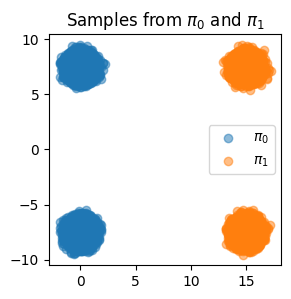

In [17]:
from matplotlib import pyplot as plt

n_samples = 50000
pi_0 = TwoPointGMM(x=0.0, y=7.5, std=0.5, device=device)
pi_1 = TwoPointGMM(x=15.0, y=7.5, std=0.5, device=device)
D0 = pi_0.sample([n_samples])
D1, labels = pi_1.sample_with_labels([n_samples])
labels.tolist()

plt.figure(figsize=(3, 3))
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
plt.scatter(D0[:, 0].cpu(), D0[:, 1].cpu(), alpha=0.5, label=r'$\pi_0$')
plt.scatter(D1[:, 0].cpu(), D1[:, 1].cpu(), alpha=0.5, label=r'$\pi_1$')
plt.legend()

In [18]:
from cleandiffuser.diffusion import DiscreteRectifiedFlow
from cleandiffuser.nn_diffusion import MlpNNDiffusion

# Define the neural network backbone
nn_diffusion = MlpNNDiffusion(x_dim=2, hidden_dims=[128, 128, 128])

# Initialize the discrete rectified flow model
model = DiscreteRectifiedFlow(
    nn_diffusion=nn_diffusion,
    diffusion_steps=1000,
    discretization="uniform",
    device=device,
)

In [19]:
n_epochs = 5000  # Define the number of epochs
for epoch in range(n_epochs):
    log = model.update(x0=D1, x1=D0)
    print(f"Epoch {epoch}, Loss: {log['loss']}")


Epoch 0, Loss: 170.2449188232422
Epoch 1, Loss: 169.6794891357422
Epoch 2, Loss: 169.1199493408203
Epoch 3, Loss: 168.56639099121094
Epoch 4, Loss: 168.0181427001953
Epoch 5, Loss: 167.47727966308594
Epoch 6, Loss: 166.92974853515625
Epoch 7, Loss: 166.37857055664062
Epoch 8, Loss: 165.8404998779297
Epoch 9, Loss: 165.2783966064453
Epoch 10, Loss: 164.72805786132812
Epoch 11, Loss: 164.16928100585938
Epoch 12, Loss: 163.62657165527344
Epoch 13, Loss: 163.05751037597656
Epoch 14, Loss: 162.48121643066406
Epoch 15, Loss: 161.90785217285156
Epoch 16, Loss: 161.3038787841797
Epoch 17, Loss: 160.72251892089844
Epoch 18, Loss: 160.13023376464844
Epoch 19, Loss: 159.49725341796875
Epoch 20, Loss: 158.8734588623047
Epoch 21, Loss: 158.2177734375
Epoch 22, Loss: 157.52444458007812
Epoch 23, Loss: 156.8332061767578
Epoch 24, Loss: 156.1367950439453
Epoch 25, Loss: 155.42491149902344
Epoch 26, Loss: 154.59689331054688
Epoch 27, Loss: 153.80921936035156
Epoch 28, Loss: 152.97447204589844
Epoch 29,

In [30]:
import torch

# Define the number of samples and the shape of each sample
n_samples = 100
x_shape = (2,)  # Shape of each sample
sample_steps=10
x1 = pi_0.sample([n_samples]) # Sample from the second distribution
# Create a prior tensor with the appropriate shape
prior = torch.zeros((n_samples, *x_shape))

# Print the shapes for verification
print(f"Sampling {n_samples} samples with shape {x_shape} from the prior. Prior shape: {prior.shape}")

# Example sampling using a model
# Assuming `model` is an instance of DiscreteRectifiedFlow or ContinuousRectifiedFlow
samples, log = model.sample(n_samples=n_samples, prior=prior, sample_steps=sample_steps, x1=x1, preserve_history=True)

# Output the shape of the generated samples
print(f"Generated samples shape: {samples.shape}")


Sampling 100 samples with shape (2,) from the prior. Prior shape: torch.Size([100, 2])
Generated samples shape: torch.Size([100, 2])


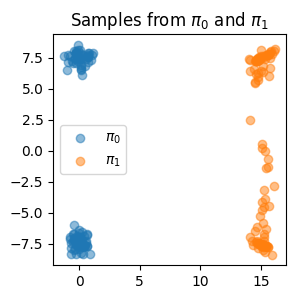

In [31]:
plt.figure(figsize=(3, 3))
plt.title(r'Samples from $\pi_0$ and $\pi_1$')
plt.scatter(x1[:, 0].cpu(), x1[:, 1].cpu(), alpha=0.5, label=r'$\pi_0$')
plt.scatter(samples[:, 0].cpu(), samples[:, 1].cpu(), alpha=0.5, label=r'$\pi_1$')
plt.legend()

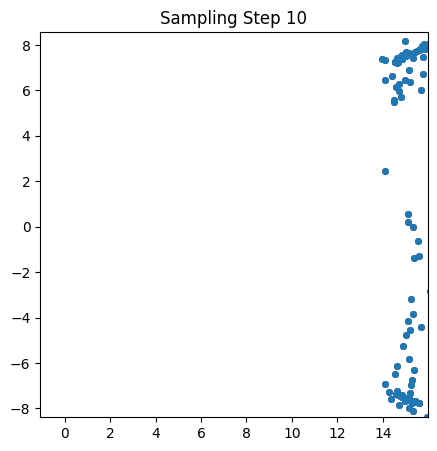

In [33]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# sample_history: (n_samples, sample_steps + 1, num_points, 2)
sample_history = log['sample_history']
n_steps = sample_history.shape[1]

fig, ax = plt.subplots(figsize=(5, 5))
scat = ax.scatter([], [], s=n_steps, alpha=0.5)
ax.set_xlim(np.min(sample_history[..., 0]), np.max(sample_history[..., 0]))
ax.set_ylim(np.min(sample_history[..., 1]), np.max(sample_history[..., 1]))
ax.set_title("Sample Evolution")
ax.axis("equal")

def update(frame):
    points = sample_history[:, frame].reshape(-1, 2)
    scat.set_offsets(points)
    ax.set_title(f"Sampling Step {frame}")
    return scat,

ani = FuncAnimation(fig, update, frames=n_steps, blit=True, interval=500)
HTML(ani.to_jshtml())
